# Tapping rhythm simulated export analysis

This notebook reads the committed simulated PsyNet export directly. Simulated tapping validates workflow and analysis code, not human rhythm perception.

In [1]:
import ast, json, tempfile, zipfile
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 50
attempt = Path.cwd().resolve()
while not (attempt / "agent.json").exists():
    if attempt.parent == attempt:
        raise RuntimeError("Could not locate attempt root")
    attempt = attempt.parent
export_zip = attempt / "evidence" / "simulated_data.zip"
manifest = json.loads((attempt / "code" / "tapping_rhythm_experiment" / "stimuli" / "manifest.json").read_text())["stimuli"]
with tempfile.TemporaryDirectory() as tmp:
    with zipfile.ZipFile(export_zip) as zf:
        zf.extractall(tmp)
    csv_paths = {str(p.relative_to(tmp)): p for p in Path(tmp).rglob("*.csv")}
    participants = pd.read_csv(csv_paths["regular/data/Bot.csv"])
    trials = pd.read_csv(csv_paths["regular/data/TappingTrial.csv"])
def parse_answer(x):
    if not isinstance(x, str) or not x:
        return None
    try:
        return json.loads(x)
    except Exception:
        return ast.literal_eval(x)
answers = [parse_answer(x) for x in trials["answer"].dropna()]
tap_df = pd.DataFrame([a for a in answers if isinstance(a, dict) and a.get("trial_kind") in {"calibration", "main"}])
expected = {"stimulus_id", "trial_kind", "simulated_profile_id", "tap_onsets", "inter_tap_intervals", "n_taps", "calibration_status", "failed", "failure_reason", "dropout"}
missing = expected - set(tap_df.columns)
assert not missing, f"Missing expected fields: {sorted(missing)}"
participant_profiles = set(participants["simulated_profile_id"])
assert {"good", "too-few-taps", "off-tempo", "noisy", "dropout"}.issubset(participant_profiles)
tap_df[["simulated_profile_id", "trial_kind", "stimulus_id", "n_taps", "calibration_status", "failed", "failure_reason", "dropout"]]


,simulated_profile_id,trial_kind,stimulus_id,n_taps,calibration_status,failed,failure_reason,dropout
0,good,calibration,calibration_100bpm,5,passed,False,NaN,False
1,good,main,main_medium_120bpm,7,not_applicable,False,NaN,False
2,good,main,main_accented_110bpm,7,not_applicable,False,NaN,False
3,good,main,main_slow_90bpm,6,not_applicable,False,NaN,False
4,too-few-taps,calibration,calibration_100bpm,2,failed,True,too_few_taps,False
5,off-tempo,calibration,calibration_100bpm,5,failed,True,off_tempo,False
6,noisy,calibration,calibration_100bpm,5,failed,True,noisy_tapping,False
7,dropout,calibration,calibration_100bpm,0,failed,True,dropout_no_taps,True


In [2]:
summary = tap_df.groupby(["simulated_profile_id", "trial_kind"], dropna=False).agg(
    trials=("stimulus_id", "count"),
    mean_taps=("n_taps", "mean"),
    failed_trials=("failed", "sum"),
).reset_index()
summary


,simulated_profile_id,trial_kind,trials,mean_taps,failed_trials
0,dropout,calibration,1,0.000000,1
1,good,calibration,1,5.000000,0
2,good,main,3,6.666667,0
3,noisy,calibration,1,5.000000,1
4,off-tempo,calibration,1,5.000000,1
5,too-few-taps,calibration,1,2.000000,1


In [3]:
interval_rows = []
for _, row in tap_df.iterrows():
    for interval in row["inter_tap_intervals"]:
        interval_rows.append({"profile": row["simulated_profile_id"], "trial_kind": row["trial_kind"], "interval": interval})
intervals = pd.DataFrame(interval_rows)
intervals.groupby(["profile", "trial_kind"], dropna=False).interval.agg(["count", "mean", "std"]).reset_index()


,profile,trial_kind,count,mean,std
0,good,calibration,4,0.596000,0.028390
1,good,main,17,0.564941,0.075324
2,noisy,calibration,4,0.545000,0.497628
3,off-tempo,calibration,4,0.810000,0.000000
4,too-few-taps,calibration,1,0.600000,NaN


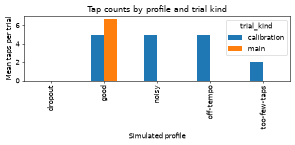

In [4]:
ax = tap_df.pivot_table(index="simulated_profile_id", columns="trial_kind", values="n_taps", aggfunc="mean").plot(kind="bar", figsize=(6, 3))
ax.set_ylabel("Mean taps per trial")
ax.set_xlabel("Simulated profile")
ax.set_title("Tap counts by profile and trial kind")
plt.tight_layout()


## Interpretation

The export should show one good profile that passes calibration and reaches main trials, while too-few, off-tempo, noisy, and dropout profiles fail calibration with distinguishable reasons. These are deterministic simulations for workflow and analysis validation only.